In [1]:
%%capture
!pip install ultralytics -q

# Import Libraries

In [2]:
from ultralytics import YOLO
import os
import shutil

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Copy Dataset to Working Directory

In [3]:
dataset_path = "/kaggle/input/datasets/guisahanes/traffic-violation-detection-dataset"
working_path = "/kaggle/working/traffic_violation"

shutil.copytree(dataset_path, working_path)
print("Dataset copied successfully!")

Dataset copied successfully!


# Fix data.yaml Path

In [4]:
yaml_file = f"{working_path}/data.yaml"

with open(yaml_file, "r") as f:
    data = f.read()

data = data.replace("/content/traffic_violation_v2", working_path)

with open(yaml_file, "w") as f:
    f.write(data)

print("data.yaml updated!")

data.yaml updated!


In [5]:
model = YOLO("yolo11m.pt")

# Train Model

In [6]:
results = model.train(
    data=yaml_file,
    epochs=150,
    imgsz=640,
    batch=32,
    device=[0,1],   # GPU
    workers=4,
    project="traffic_violation",
    name="yolo11m_training"
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/traffic_violation/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo1

# Validate Model

In [7]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,047,765 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 947.6±531.2 MB/s, size: 24.5 KB)
val: Scanning /kaggle/working/traffic_violation/labels/val.cache... 1470 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1470/1470 411.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 92/92 2.0it/s 44.9s
                   all       1470       1592      0.928      0.877      0.927       0.81
                person         50         50      0.809       0.86      0.878      0.765
                   car        172        172      0.836      0.711       0.83      0.703
                 truck        167        167      0.689      0.653      0.725      0.587
                   bus         95         95      0.764       0.58      0.747      0.646
            motorcycle   

# Run Inference on Validation Images

In [8]:
model = YOLO("/kaggle/working/runs/detect/traffic_violation/yolo11m_training/weights/best.pt")

results = model.predict(
    source=f"{working_path}/images/val",
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1470 /kaggle/working/traffic_violation/images/val/bdd_b1ceb32e-a106591d_crop0_crop0.jpg: 640x608 1 truck, 59.2ms
image 2/1470 /kaggle/working/traffic_violation/images/val/bdd_b1f25ff6-1ddb7e43_crop0_crop0.jpg: 544x640 1 motorcycle, 60.7ms
image 3/1470 /kaggle/working/traffic_violation/images/val/bdd_b1f4491b-09593e90_crop0_crop0.jpg: 640x544 1 truck, 52.2ms
image 4/1470 /kaggle/working/traffic_violation/images/val/bdd_b1f4491b-09593e90_crop1_crop

# Show Prediction Results

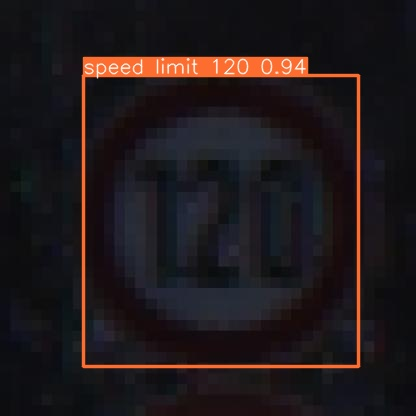

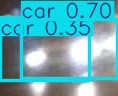

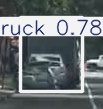

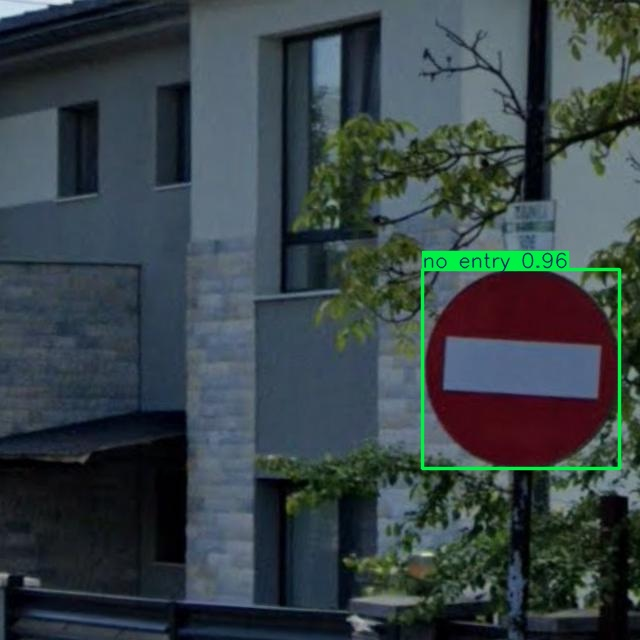

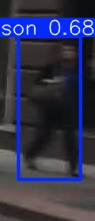

In [9]:
from IPython.display import Image, display
import glob

images = glob.glob("runs/detect/predict/*.jpg")

for img in images[:5]:
    display(Image(filename=img))

# Export Model

In [10]:
model.export(format="onnx")

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/detect/traffic_violation/yolo11m_training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 27, 8400) (38.7 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 378ms
 Downloaded onnxruntime
Prepared 2 packages in 318ms
Installed 2 packages in 12ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 4.6s, saved as '/kaggle/working/run

'/kaggle/working/runs/detect/traffic_violation/yolo11m_training/weights/best.onnx'